## TASK 1:

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../../cleaned_data/Telco-Customer-Churn.csv')
print(df.head())
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

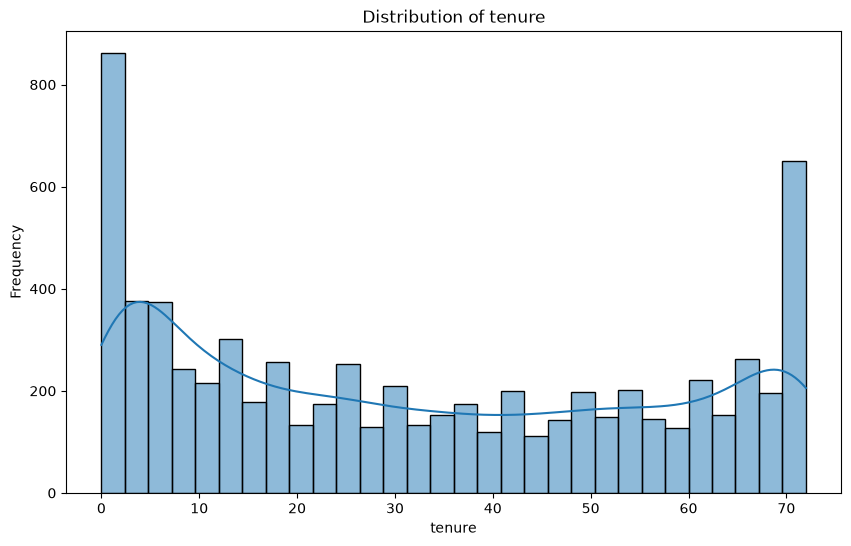

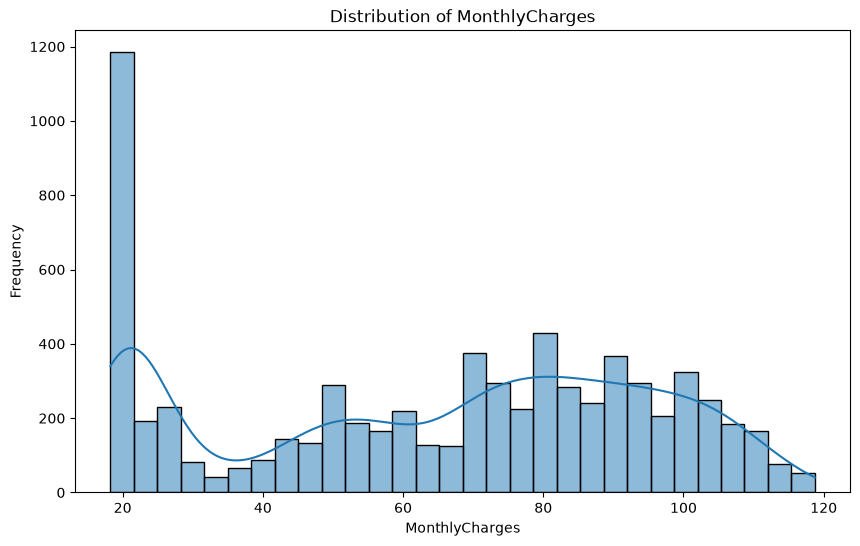

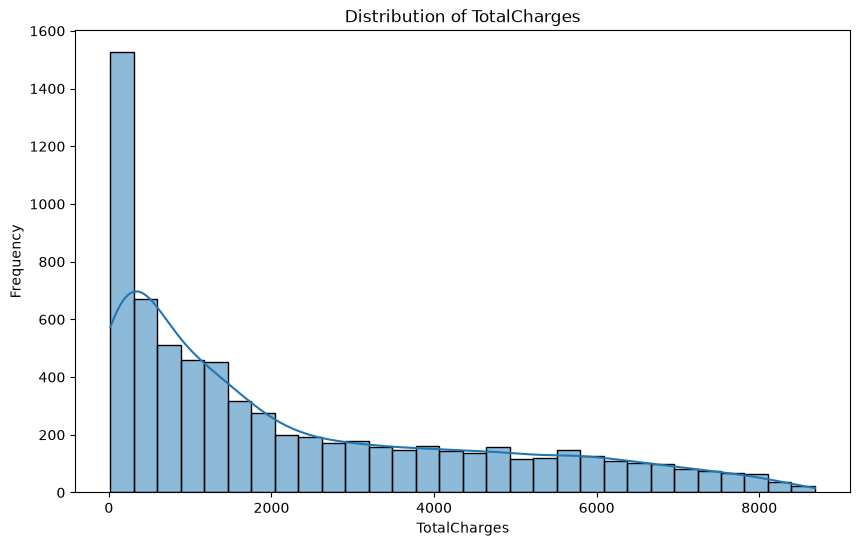

In [8]:
cols=['tenure','MonthlyCharges','TotalCharges']

for col in cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], bins=30, kde=True)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

TotalCharges is completely right skewed. Tenure and MonthlyCharges are not normal, they look bimodal.They have two peaks instead of one. Tenure has one peak for new customers and one peak for long-term customers. MonthlyCharges has one peak near $20 and another peak around $70-100.

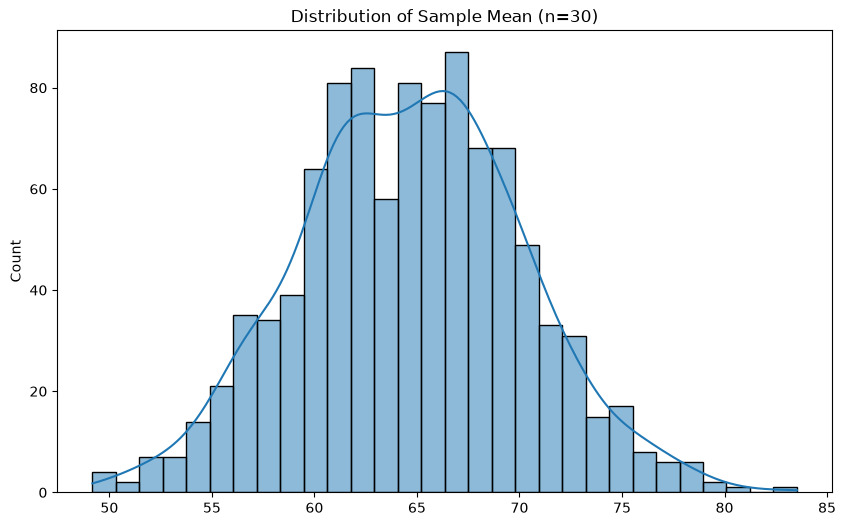

In [9]:
sample_means=[]

for i in range(1000):
    sample=df['MonthlyCharges'].sample(n=30)
    sample_mean=sample.mean()
    sample_means.append(sample_mean)

sample_means=pd.Series(sample_means)

plt.figure(figsize=(10,6))
sns.histplot(sample_means, bins=30, kde=True)
plt.title("Distribution of Sample Mean (n=30)")
plt.show()

In [11]:
from scipy.stats import binom

n=30
p=0.27
k=8

prob=binom.pmf(k,n,p)
print(f"Probability of exactly {k} successes in {n} trials with success probability {p}: {prob.round(4)}")

Probability of exactly 8 successes in 30 trials with success probability 0.27: 0.1627


## TASK 2:

In [13]:
from scipy import stats

ct=pd.crosstab(df['Contract'], df['Churn'])
print(ct)

chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"chi2={chi2:.2f}, dof={dof}, p-value={p}")

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
chi2=1184.60, dof=2, p-value=5.863038300673391e-258


This p-value is so tiny it's basically saying "there's no way this happened by luck." Month-to-month customers churn a lot (43%), two-year contract customers barely churn at all (3%). Contract type really does affect churn.

In [ ]:
churned = df[df['Churn']=='Yes']['MonthlyCharges']
not_churned = df[df['Churn']=='No']['MonthlyCharges']

print(stats.shapiro(churned.sample(500)))
print(stats.shapiro(not_churned.sample(500)))

ShapiroResult(statistic=np.float64(0.9254831790495414), pvalue=np.float64(4.8134135592455764e-15))
ShapiroResult(statistic=np.float64(0.9057327447859495), pvalue=np.float64(4.81520900043733e-17))


In [15]:

t_stat, p_t = stats.ttest_ind(churned, not_churned, equal_var=False)

u_stat, p_u = stats.mannwhitneyu(churned, not_churned, alternative='two-sided')

Churned customers pay more on average ($74/month) than customers who stayed ($61/month). This p-value tells us that gap is way too big to be a coincidence. It's a real difference.


In [16]:
ct2 = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(ct2)
print(f"chi2={chi2:.2f}, dof={dof}, p-value={p}")

print(df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()))

chi2=648.14, dof=3, p-value=3.6823546520097993e-140
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


Again, way too small to be luck. People who pay by electronic check churn a LOT more (45%) than people on auto-pay methods like credit card or bank transfer (15-19%). Payment method really is connected to churn.

## TASK 3:

In [19]:

print(df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()))

print(df.groupby('InternetService')['MonthlyCharges'].mean())

print(df.groupby('InternetService')['tenure'].mean())

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64
InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64
InternetService
DSL            32.821561
Fiber optic    32.917959
No             30.547182
Name: tenure, dtype: float64


The correlation: Fiber optic customers churn at 41.9%, more than double the DSL rate of 19.0%, and far above the 7.4% for customers with no internet service.

The confounder: Fiber optic customers also pay $91.50/month on average about $33 more than DSL customers at $58.10. Tenure is nearly identical across all three groups (~31-33 months), so it's not that fiber customers are newer or less loyal by default. This points to price as a likely confounder: fiber is simply the most expensive plan, and we already found earlier that higher MonthlyCharges is linked to higher churn regardless of service type.

Why we can't call it causal: In this data, "has fiber" and "pays a high bill" overlap almost completely, so we can't separate whether people leave because of fiber optic itself or simply because of the price tag attached to it. To actually test if fiber causes churn, you'd need to compare fiber and DSL customers at similar price points, or run a controlled experiment the correlation alone doesn't get you there.